# Задание 2. HMM — Viterbi, Forward, Backward (log-space)


Posledovatelnost: `CTTCATGTGAAAGCAGACGTAAGTCA`
Последовательность может оборватьься только на интроне с вероятностью 0.1. Это учитывается во всех алгоритмах. Без этого - результат работы алгоритма отличается от последовательности из статьи, так как, грубо говоря, вероятность остаться в E будет превосходить вероятность перехода в 5 на данной длине последовательности.

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# параметры модели
states = ['E', '5', 'I']
obs_symbols = ['A', 'C', 'G', 'T']
state_idx = {s: i for i, s in enumerate(states)}
obs_idx = {o: i for i, o in enumerate(obs_symbols)}

# Начальные вероятности
pi = np.array([1.0, 0.0, 0.0])

# Матрица перехода
A = np.array([
    [0.9, 0.1, 0.0],   # E -> E(0.9), 5(0.1)
    [0.0, 0.0, 1.0],   # 5 -> I(1.0)
    [0.0, 0.0, 0.9]    # I -> I(0.9), end(0.1)
])

# Вероятность обрыва
p_end = np.array([0.0, 0.0, 0.1])  # tolko iz I

# MМатрица эмиссий B [A, C, G, T]
B = np.array([
    [0.25, 0.25, 0.25, 0.25],  # E
    [0.05, 0.00, 0.95, 0.00],  # 5
    [0.40, 0.10, 0.10, 0.40],  # I
])

sequence = 'CTTCATGTGAAAGCAGACGTAAGTCA'
obs = [obs_idx[c] for c in sequence]
T_len = len(obs)
N = len(states)

print(f'Длина последовательности: {T_len}')
print(f'Последовательность: {sequence}')

Длина последовательности: 26
Последовательность: CTTCATGTGAAAGCAGACGTAAGTCA


In [18]:
def logsumexp(a):
    """Stable log-sum-exp."""
    a = np.array(a)
    c = np.max(a)
    if c == -np.inf:
        return -np.inf
    return c + np.log(np.sum(np.exp(a - c)))

## 2.1 Algoritm Viterbi (log-space, s terminatsiey)

In [19]:
def viterbi_log(obs, pi, A, B, p_end, states):
    N = len(states)
    T = len(obs)
    
    log_pi = np.log(pi + 1e-300)
    log_A = np.log(A + 1e-300)
    log_B = np.log(B + 1e-300)
    log_end = np.log(p_end + 1e-300)
    
    delta = np.full((T, N), -np.inf)
    psi = np.zeros((T, N), dtype=int)
    
    for i in range(N):
        delta[0, i] = log_pi[i] + log_B[i, obs[0]]
    
    for t in range(1, T):
        for j in range(N):
            candidates = delta[t-1, :] + log_A[:, j]
            psi[t, j] = np.argmax(candidates)
            delta[t, j] = candidates[psi[t, j]] + log_B[j, obs[t]]
    
    # обрыв - домножаем на P(end|state)
    final_scores = delta[-1, :] + log_end
    
    # Backtracking
    path = np.zeros(T, dtype=int)
    path[-1] = np.argmax(final_scores)
    best_log_prob = final_scores[path[-1]]
    
    for t in range(T-2, -1, -1):
        path[t] = psi[t+1, path[t+1]]
    
    return [states[s] for s in path], best_log_prob, delta

viterbi_path, viterbi_log_prob, delta_matrix = viterbi_log(obs, pi, A, B, p_end, states)

print('Viterbi put:')
print(''.join(viterbi_path))
print(f'\nSekvens:  {sequence}')
print(f'\nLog-veroyatnost: {viterbi_log_prob:.6f}')
print(f'вероятность:     {np.exp(viterbi_log_prob):.6e}')

# статья
eddy_path = 'EEEEEEEEEEEEEEEEEE5IIIIIII'
print(f'\nпуть из статьи:  {eddy_path}')
our_path = ''.join(viterbi_path)
match = sum(a == b for a, b in zip(our_path, eddy_path))
print(f'наш путь:                  {our_path}')
print(f'совпадение позиций:       {match}/{T_len}')
if our_path == eddy_path:
    print('\nрасхождений нет')
else:
    print(f'\nрасхождение на позициях: ', end='')
    diffs = [str(i+1) for i,(a,b) in enumerate(zip(our_path, eddy_path)) if a != b]
    print(', '.join(diffs))

Viterbi put:
EEEEEEEEEEEEEEEEEE5IIIIIII

Sekvens:  CTTCATGTGAAAGCAGACGTAAGTCA

Log-veroyatnost: -41.219678
вероятность:     1.254647e-18

путь из статьи:  EEEEEEEEEEEEEEEEEE5IIIIIII
наш путь:                  EEEEEEEEEEEEEEEEEE5IIIIIII
совпадение позиций:       26/26

расхождений нет


## 2.2 Algoritm Forward (log-space, s terminatsiey)

In [20]:
def forward_log(obs, pi, A, B, p_end, states):
    N = len(states)
    T = len(obs)
    
    log_pi = np.log(pi + 1e-300)
    log_A = np.log(A + 1e-300)
    log_B = np.log(B + 1e-300)
    log_end = np.log(p_end + 1e-300)
    
    alpha = np.full((T, N), -np.inf)
    
    for i in range(N):
        alpha[0, i] = log_pi[i] + log_B[i, obs[0]]
    
    for t in range(1, T):
        for j in range(N):
            alpha[t, j] = logsumexp(alpha[t-1, :] + log_A[:, j]) + log_B[j, obs[t]]
    
    # обрыв: P(O|lambda) = sum_i alpha_T(i) * P(end|i)
    log_prob = logsumexp(alpha[-1, :] + log_end)
    return alpha, log_prob

alpha, forward_log_prob = forward_log(obs, pi, A, B, p_end, states)

print(f'Log-вероятность P(O|lambda): {forward_log_prob:.6f}')
print(f'вероятность P(O|lambda):     {np.exp(forward_log_prob):.6e}')

Log-вероятность P(O|lambda): -40.447426
вероятность P(O|lambda):     2.715851e-18


## 2.3 algoritm backward + апостериорное декодироваие (gamma)

In [21]:
def backward_log(obs, A, B, p_end, states):
    N = len(states)
    T = len(obs)
    
    log_A = np.log(A + 1e-300)
    log_B = np.log(B + 1e-300)
    log_end = np.log(p_end + 1e-300)
    
    beta = np.full((T, N), -np.inf)
    
    # инициализация: beta_T(i) = P(end|i)
    beta[-1, :] = log_end
    
    for t in range(T-2, -1, -1):
        for i in range(N):
            beta[t, i] = logsumexp(log_A[i, :] + log_B[:, obs[t+1]] + beta[t+1, :])
    
    return beta

beta = backward_log(obs, A, B, p_end, states)

# проверка
log_pi = np.log(pi + 1e-300)
log_B = np.log(B + 1e-300)
bwd_log_prob = logsumexp(log_pi + log_B[:, obs[0]] + beta[0, :])
print(f'проверка Backward: log P(O|lambda) = {bwd_log_prob:.6f}')
print(f'Forward:           log P(O|lambda) = {forward_log_prob:.6f}')
print(f'разница: {abs(bwd_log_prob - forward_log_prob):.2e}')

проверка Backward: log P(O|lambda) = -40.447426
Forward:           log P(O|lambda) = -40.447426
разница: 1.42e-14


In [22]:

log_gamma = alpha + beta - forward_log_prob
gamma = np.exp(log_gamma)

print('проверка: сумма гамма по состояниям:')
sums = gamma.sum(axis=1)
print(f'min={sums.min():.6f}, max={sums.max():.6f}')

проверка: сумма гамма по состояниям:
min=1.000000, max=1.000000


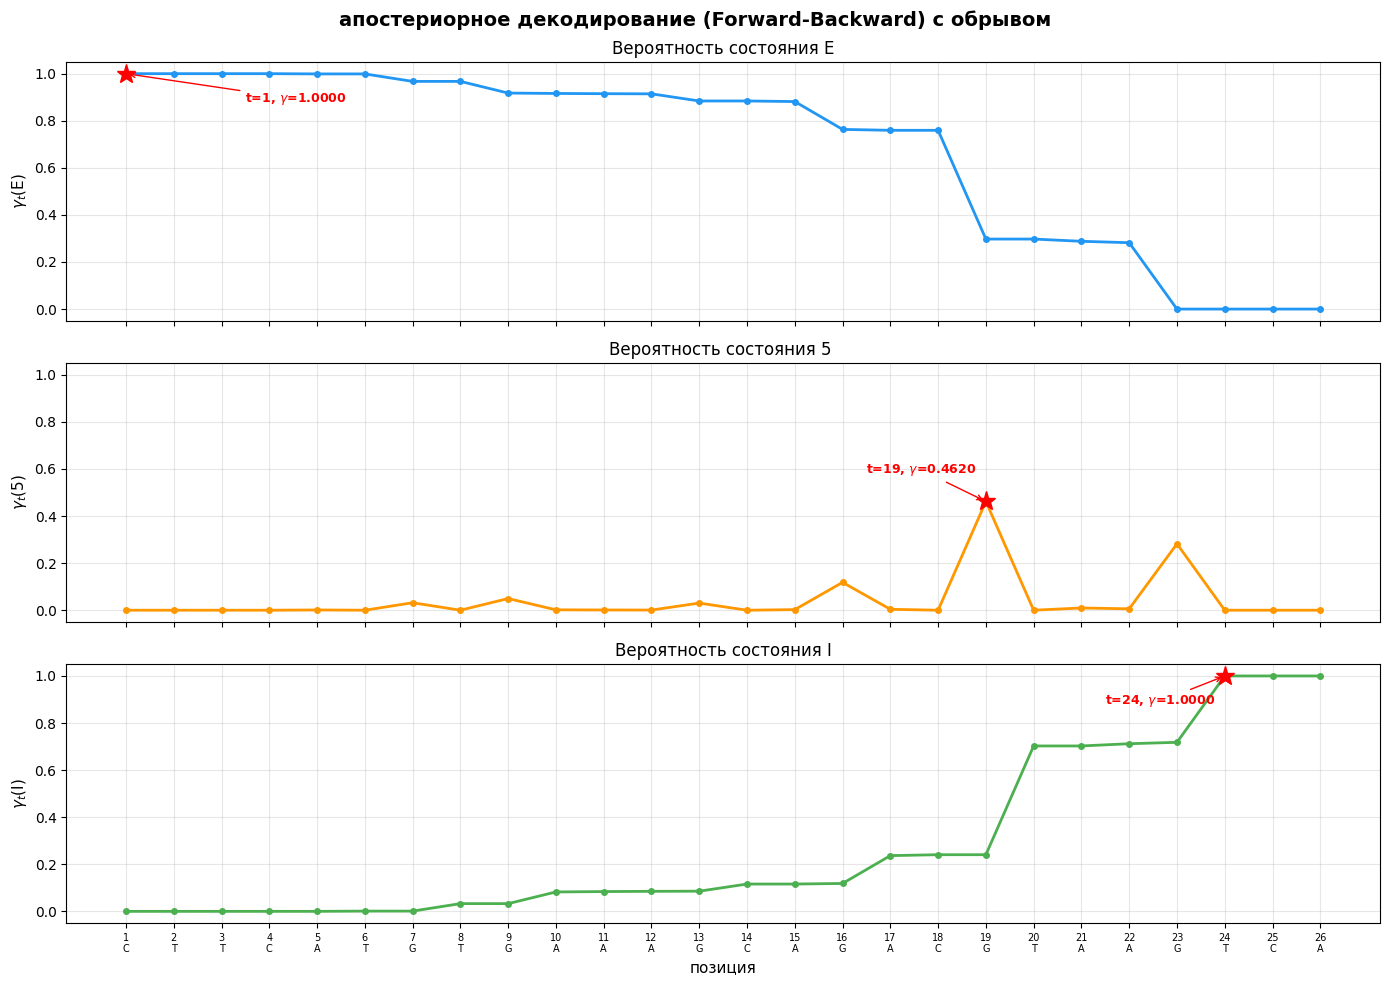

Максимы:
  E: t=1, gamma=1.000000
  5 : t=19, gamma=0.461972
  I: t=24, gamma=1.000000


In [23]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
t_range = np.arange(1, T_len + 1)

labels = ['E', '5 ', 'I']
colors_list = ['#2196F3', '#FF9800', '#4CAF50']

for idx in range(3):
    ax = axes[idx]
    probs = gamma[:, idx]
    ax.plot(t_range, probs, 'o-', color=colors_list[idx], linewidth=2, markersize=4)
    ax.set_ylabel(f'$\\gamma_t$({states[idx]})', fontsize=11)
    ax.set_title(f'Вероятность состояния {labels[idx]}', fontsize=12)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    
    # Ищем максима
    max_idx = np.argmax(probs)
    max_val = probs[max_idx]
    
    if max_val > 0.01:
        x_off = -2.5 if max_idx > T_len / 2 else 2.5
        y_off = -0.12 if max_val > 0.5 else 0.12
        ax.annotate(f't={max_idx+1}, $\\gamma$={max_val:.4f}',
                    xy=(max_idx+1, max_val),
                    xytext=(max_idx+1+x_off, max_val+y_off),
                    fontsize=9, color='red', fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color='red'))
        ax.plot(max_idx+1, max_val, 'r*', markersize=14)

axes[2].set_xticks(t_range)
axes[2].set_xticklabels([f'{t}\n{sequence[t-1]}' for t in t_range], fontsize=7)
axes[2].set_xlabel('позиция', fontsize=11)

plt.suptitle('апостериорное декодирование (Forward-Backward) с обрывом', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('gamma_plots.png', dpi=150, bbox_inches='tight')
plt.show()

# максимы
print('Максимы:')
for idx in range(3):
    probs = gamma[:, idx]
    max_pos = np.argmax(probs) + 1
    max_val = probs[max_pos - 1]
    print(f'  {labels[idx]}: t={max_pos}, gamma={max_val:.6f}')